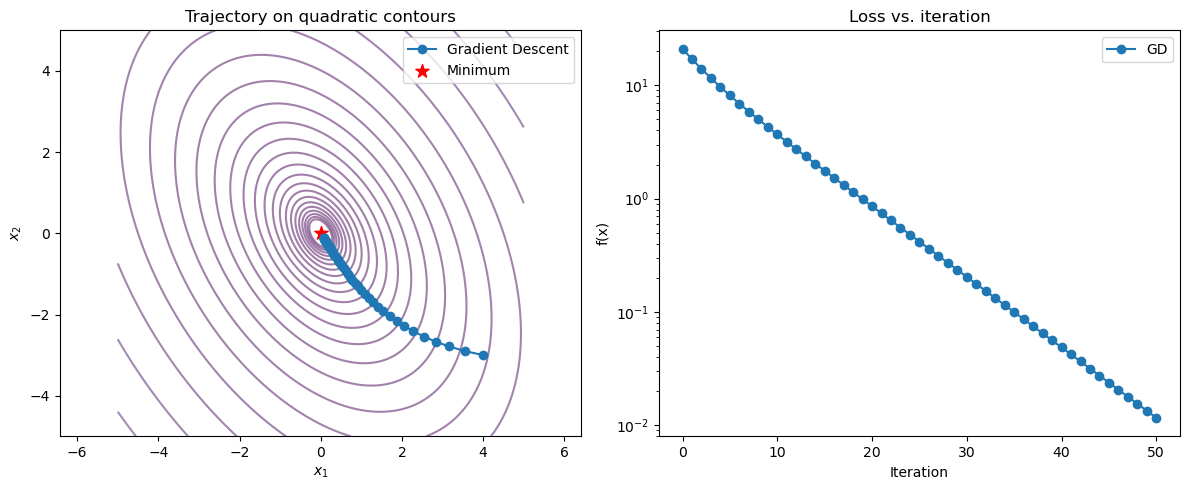

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Problem setup -------------------------------------------------------
# Positive–definite 2×2 matrix → f(x) = ½ xᵀAx
A = np.array([[3.0, 1.0],
              [1.0, 2.0]])

def f(x):
    return 0.5 * x.T @ A @ x

def grad(x):
    return A @ x

# Hyper-parameters
α = 0.05            # step size
n_iter = 50         # iterations
x0 = np.array([4.0, -3.0])   # starting point

# ---- Gradient Descent ----------------------------------------------------
gd_path = [x0.copy()]
x = x0.copy()
for _ in range(n_iter):
    x = x - α * grad(x)
    gd_path.append(x.copy())

gd_path = np.array(gd_path)

# ---- Prepare contour grid ------------------------------------------------
x1 = np.linspace(-5, 5, 200)
x2 = np.linspace(-5, 5, 200)
X1, X2 = np.meshgrid(x1, x2)
Z = 0.5 * (A[0,0]*X1**2 + 2*A[0,1]*X1*X2 + A[1,1]*X2**2)

# ---- Loss curve data -----------------------------------------------------
gd_loss = [f(p) for p in gd_path]

# ---- Single figure with 2 subplots ---------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# (Left) contour + trajectory
levels = np.logspace(-1, 3, 30)
axs[0].contour(X1, X2, Z, levels=levels, alpha=0.5)
axs[0].plot(gd_path[:, 0], gd_path[:, 1], 'o-', label='Gradient Descent')
axs[0].scatter(0, 0, c='red', marker='*', s=100, label='Minimum')
axs[0].set_xlabel(r'$x_1$')
axs[0].set_ylabel(r'$x_2$')
axs[0].set_title('Trajectory on quadratic contours')
axs[0].legend()
axs[0].axis('equal')

# (Right) loss curve
axs[1].plot(gd_loss, 'o-', label='GD')
axs[1].set_yscale('log')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel('f(x)')
axs[1].set_title('Loss vs. iteration')
axs[1].legend()

plt.tight_layout()
plt.savefig("gd_both.pdf", bbox_inches="tight")
plt.show()